In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
import seaborn as sns

# IMPORT DATA

In [2]:
df = pd.read_csv('Caffe Sales.csv')
df_raw = df.copy()  # Simpan salinan data mentah untuk referensi
df

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2,2.0,4.0,NaN,UNKNOWN,2023-08-30
9996,TXN_9659401,NaN,3,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3,NaN,3.0,Digital Wallet,NaN,2023-12-02


# DATA EXPLORATION

In [3]:
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


In [5]:
df.describe()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
count,10000,9667,9862,9821,9827,7421,6735,9841
unique,10000,10,7,8,19,5,4,367
top,TXN_6170729,Juice,5,3.0,6.0,Digital Wallet,Takeaway,UNKNOWN
freq,1,1171,2013,2429,979,2291,3022,159


In [6]:
# Banyak kolom dan baris pada dataset
print(f"Banyak kolom: {df.shape[1]}")
print(f"Banyak baris: {df.shape[0]}")
df.columns

Banyak kolom: 8
Banyak baris: 10000


Index(['Transaction ID', 'Item', 'Quantity', 'Price Per Unit', 'Total Spent',
       'Payment Method', 'Location', 'Transaction Date'],
      dtype='object')

In [7]:
# Cek nilai unik dari "Item", "Quantity", "Payment Method", "Location"
print("Nilai unik dari 'Item':")
print(df['Item'].unique())

print("\nNilai unik dari 'Quantity':")
print(df['Quantity'].unique())

print("\nNilai unik dari 'Price Per Unit':")
print(df['Price Per Unit'].unique())

print("\nNilai unik dari 'Payment Method':")
print(df['Payment Method'].unique())

print("\nNilai unik dari 'Location':")
print(df['Location'].unique())

Nilai unik dari 'Item':
['Coffee' 'Cake' 'Cookie' 'Salad' 'Smoothie' 'UNKNOWN' 'Sandwich' nan
 'ERROR' 'Juice' 'Tea']

Nilai unik dari 'Quantity':
['2' '4' '5' '3' '1' 'ERROR' 'UNKNOWN' nan]

Nilai unik dari 'Price Per Unit':
['2.0' '3.0' '1.0' '5.0' '4.0' '1.5' nan 'ERROR' 'UNKNOWN']

Nilai unik dari 'Payment Method':
['Credit Card' 'Cash' 'UNKNOWN' 'Digital Wallet' 'ERROR' nan]

Nilai unik dari 'Location':
['Takeaway' 'In-store' 'UNKNOWN' nan 'ERROR']


In [8]:
# Cek jumlah tiap nilai unik
print("Jumlah tiap item:")
print(df['Item'].value_counts())

print("\nJumlah tiap 'Quantity':")
print(df['Quantity'].value_counts())

print("\nJumlah tiap 'Price Per Unit':")
print(df['Price Per Unit'].value_counts())

print("\nJumlah tiap 'Payment Method':")
print(df['Payment Method'].value_counts())

print("\nJumlah tiap 'Location':")
print(df['Location'].value_counts())

Jumlah tiap item:
Item
Juice       1171
Coffee      1165
Salad       1148
Cake        1139
Sandwich    1131
Smoothie    1096
Cookie      1092
Tea         1089
UNKNOWN      344
ERROR        292
Name: count, dtype: int64

Jumlah tiap 'Quantity':
Quantity
5          2013
2          1974
4          1863
3          1849
1          1822
UNKNOWN     171
ERROR       170
Name: count, dtype: int64

Jumlah tiap 'Price Per Unit':
Price Per Unit
3.0        2429
4.0        2331
2.0        1227
5.0        1204
1.0        1143
1.5        1133
ERROR       190
UNKNOWN     164
Name: count, dtype: int64

Jumlah tiap 'Payment Method':
Payment Method
Digital Wallet    2291
Credit Card       2273
Cash              2258
ERROR              306
UNKNOWN            293
Name: count, dtype: int64

Jumlah tiap 'Location':
Location
Takeaway    3022
In-store    3017
ERROR        358
UNKNOWN      338
Name: count, dtype: int64


In [9]:
# Cek tipe data
df.dtypes

Transaction ID      object
Item                object
Quantity            object
Price Per Unit      object
Total Spent         object
Payment Method      object
Location            object
Transaction Date    object
dtype: object

In [10]:
# Semua kolom memiliki tipe data object, harus segera diubah untuk menampilkan histogram
df['Quantity'] = pd.to_numeric(df['Quantity'].str.strip(), errors = "coerce")
df['Price Per Unit'] = pd.to_numeric(df['Price Per Unit'].str.strip(), errors = "coerce")
df['Total Spent'] = pd.to_numeric(df['Total Spent'].str.strip(), errors = "coerce")
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'].str.strip(), format="%Y-%m-%d", errors = "coerce")

In [11]:
df.dtypes

Transaction ID              object
Item                        object
Quantity                   float64
Price Per Unit             float64
Total Spent                float64
Payment Method              object
Location                    object
Transaction Date    datetime64[ns]
dtype: object

In [12]:
# Cek null value pada dataset
print("Jumlah null value pada setiap kolom:")
print(df.isnull().sum())

Jumlah null value pada setiap kolom:
Transaction ID         0
Item                 333
Quantity             479
Price Per Unit       533
Total Spent          502
Payment Method      2579
Location            3265
Transaction Date     460
dtype: int64


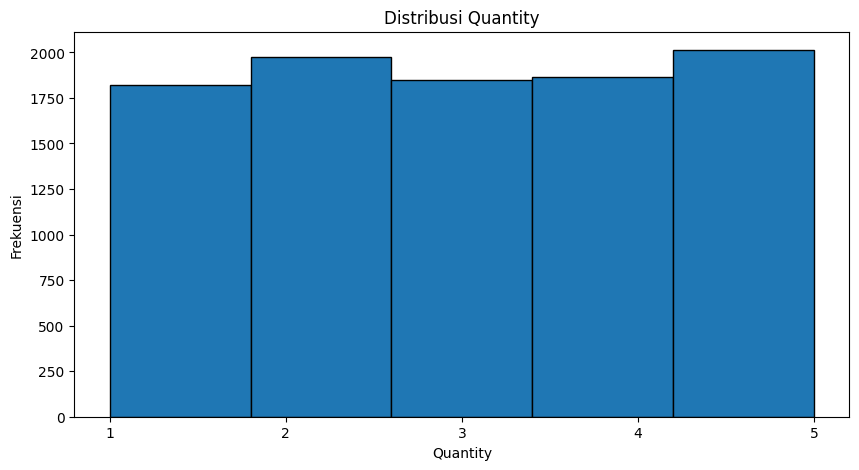

In [13]:
# Histogram Quantity

plt.figure(figsize=(10, 5))
plt.hist(df['Quantity'], bins=5, edgecolor="black")
plt.title("Distribusi Quantity")
plt.xlabel("Quantity")
plt.ylabel("Frekuensi")
plt.xticks([1, 2, 3, 4, 5])
plt.show()

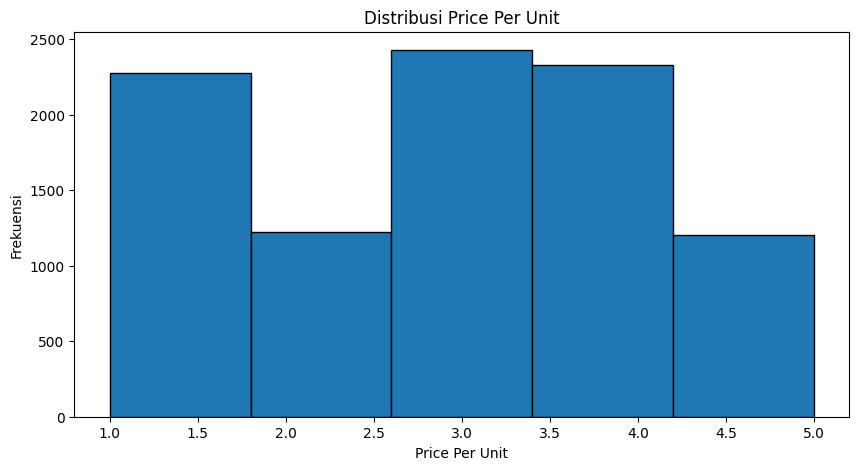

In [14]:
# Histogram Price per unit
plt.figure(figsize=(10, 5))
plt.hist(df['Price Per Unit'], bins=5, edgecolor="black")
plt.title("Distribusi Price Per Unit")
plt.xlabel("Price Per Unit")
plt.ylabel("Frekuensi")
plt.show()

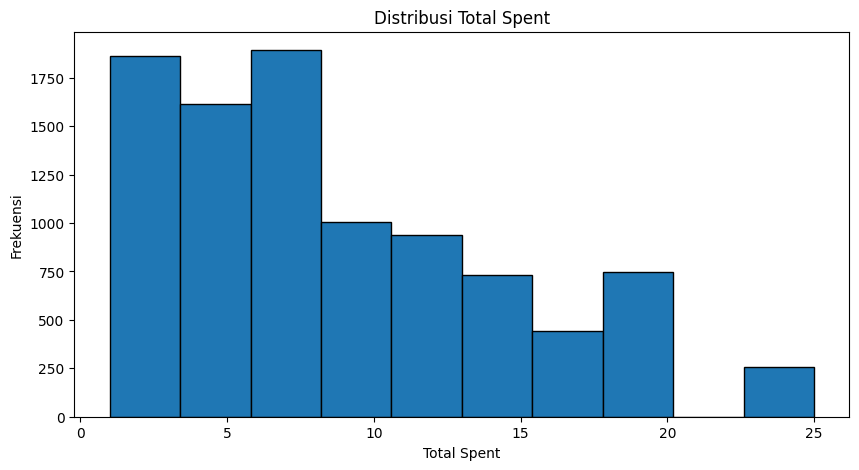

In [15]:
# Histogram Total Spent
plt.figure(figsize=(10, 5))
plt.hist(df['Total Spent'], bins=10, edgecolor="black")
plt.title("Distribusi Total Spent")
plt.xlabel("Total Spent")
plt.ylabel("Frekuensi")
plt.show()

In [16]:
# Analisa Transaction Date
print("Frekuensi nilai Transaction Date")
print("Tahun transaksi:", df['Transaction Date'].dt.year.unique())
print("Jumlah Transaksi Tiap Bulan:")
print(df['Transaction Date'].dt.month.value_counts().sort_index())

Frekuensi nilai Transaction Date
Tahun transaksi: [2023.   nan]
Jumlah Transaksi Tiap Bulan:
Transaction Date
1.0     818
2.0     727
3.0     827
4.0     774
5.0     777
6.0     818
7.0     791
8.0     803
9.0     788
10.0    838
11.0    784
12.0    795
Name: count, dtype: int64


# DATA CLEANING

Menangani missing values (menghapus atau mengisi dengan nilai tertentu).

In [17]:
# Mengingat ada nilai ERROR dan UNKNOWN, ini semua diubah ke null
count_item_er = df['Item'].isin(['ERROR', 'UNKNOWN']).sum()
coun_qty_er = df['Quantity'].isin(['ERROR', 'UNKNOWN']).sum()
count_price_er = df['Price Per Unit'].isin(['ERROR', 'UNKNOWN']).sum()
count_loc_er = df['Location'].isin(['ERROR', 'UNKNOWN']).sum()

print(count_item_er)
print(coun_qty_er)
print(count_price_er)
print(count_loc_er)


636
0
0
696


In [18]:
# Cek null value pada dataset
print("Jumlah null value pada setiap kolom:")
print(df.isnull().sum())

Jumlah null value pada setiap kolom:
Transaction ID         0
Item                 333
Quantity             479
Price Per Unit       533
Total Spent          502
Payment Method      2579
Location            3265
Transaction Date     460
dtype: int64


In [19]:
# Tampilkan Item dan Price Per Unit
df.groupby(['Item', 'Price Per Unit']).size().reset_index(name='count') # Terlihat item yang sama pasti punya harga yang pasti

,Item,Price Per Unit,count
0,Cake,3.0,1085
1,Coffee,2.0,1108
2,Cookie,1.0,1026
3,ERROR,1.0,34
4,ERROR,1.5,37
5,ERROR,2.0,31
6,ERROR,3.0,77
7,ERROR,4.0,61
8,ERROR,5.0,39
9,Juice,3.0,1110


In [20]:
# Tampilkan Item dan Price Per Unit (exclude UNKNOWN dan ERROR)
df_filtered = df[~df['Item'].isin(['ERROR', 'UNKNOWN'])]
df_filtered.groupby(['Item', 'Price Per Unit']).size().reset_index(name='count')

,Item,Price Per Unit,count
0,Cake,3.0,1085
1,Coffee,2.0,1108
2,Cookie,1.0,1026
3,Juice,3.0,1110
4,Salad,5.0,1082
5,Sandwich,4.0,1082
6,Smoothie,4.0,1036
7,Tea,1.5,1023


In [21]:
# Terlihat pola harga per item
# Dapat mengisi Price Per Unit yang Null
price_map = {
    'Coffee': 2.0,
    'Cake': 3.0,
    'Juice': 3.0,
    'Cookie': 1.0,
    'Sandwich': 4.0,
    'Smoothie': 4.0,
    'Tea': 1.5,
    'Salad': 5.0
}

mask = df['Price Per Unit'].isnull() | df['Price Per Unit'].isin(["ERROR", "UNKNOWN"])
df.loc[mask, 'Price Per Unit'] = df.loc[mask, 'Item'].map(price_map)

In [22]:
# Cek null value pada dataset
print("Jumlah null value pada kolom Price Per Unit:")
print(df['Price Per Unit'].isnull().sum()) # Masih tersisa untuk item yang ERROR dan UNKNOWN

Jumlah null value pada kolom Price Per Unit:
54


In [23]:
# Bandingkan dengan total spent dan quantity
mask = (
    df['Price Per Unit'].isnull() &
    df['Quantity'].notna() &
    df['Total Spent'].notna()
)

df.loc[mask, 'Price Per Unit'] = df.loc[mask, 'Total Spent'] / df.loc[mask, 'Quantity']

In [24]:
# Cek null value pada dataset
print("Jumlah null value pada kolom Price Per Unit:")
print(df['Price Per Unit'].isnull().sum()) # Masih tersisa untuk price per unit yang null (total spentnya kosong atau/dan quantitynya kosong)

Jumlah null value pada kolom Price Per Unit:
6


In [25]:
# Keputusan: DROP Price Per Unit yang masuh null
mask = (df['Price Per Unit'].isnull())
# Masukkan ke df_drop untuk analisa lebih lanjut
df_drop = df[mask]
df = df[~mask]

In [26]:
# Cek null value pada dataset
print("Jumlah null value pada kolom Price Per Unit:")
print(df['Price Per Unit'].isnull().sum() + df['Price Per Unit'].isin(["ERROR", "UNKNOWN"]).sum())

Jumlah null value pada kolom Price Per Unit:
0


In [27]:
# Isi Item, cukup yang pasti
item_map  = {
    1.0: 'Cookie', 1.5: 'Tea',
    2.0: 'Coffee', 5.0: 'Salad'
}

mask = (df['Item'].isnull()) | (df['Item'] == "ERROR") | (df['Item'] == "UNKNOWN")
df.loc[mask, 'Item'] = df.loc[mask, 'Price Per Unit'].map(item_map)

In [28]:
df[(df['Item'].isnull()) | (df['Item'] == "ERROR") | (df['Item'] == "UNKNOWN")]['Price Per Unit'].value_counts()
# Price dengan nilai 3 dan 4 merupakan nilai yang tidak bisa ditentukan apa itemnya(ambigu)

Price Per Unit
3.0    247
4.0    227
Name: count, dtype: int64

In [29]:
# Keputusan: Isi dengan probabilitas
np.random.seed(42)

total_3 = 1085 + 1110
total_4 = 1082 + 1036

mask_3 = ((df['Item'].isnull()) | (df["Item"] == "ERROR") | (df['Item'] == "UNKNOWN")) & (df['Price Per Unit'] == 3.0)
mask_4 = ((df['Item'].isnull()) | (df["Item"] == "ERROR") | (df['Item'] == "UNKNOWN")) & (df['Price Per Unit'] == 4.0)

df.loc[mask_3, 'Item'] = np.random.choice(
    ['Cake', 'Juice'],
    size=mask_3.sum(),
    p=[1085/total_3, 1110/total_3]
)

df.loc[mask_4, 'Item'] = np.random.choice(
    ['Sandwich', 'Smoothie'],
    size=mask_4.sum(),
    p=[1082/total_4, 1036/total_4]
)

In [30]:
# Cek null value pada dataset
print("Jumlah null value pada kolom 'Item':")
print(df['Item'].isnull().sum() + df['Item'].eq("ERROR").sum() + df['Item'].eq("UNKNOWN").sum()) # Item sudah tidak ada yang null, unknown dan error

Jumlah null value pada kolom 'Item':
0


In [31]:
df[(df['Quantity'].isnull()) & (df['Total Spent'].notna())] # 456 data quantity yang null dapat diisi dengan Total Spent dibagi Price Per Unit

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
20,TXN_3522028,Smoothie,NaN,4.0,20.0,Cash,In-store,2023-04-04
55,TXN_5522862,Cookie,NaN,1.0,2.0,Credit Card,Takeaway,2023-03-19
57,TXN_2080895,Cake,NaN,3.0,3.0,Digital Wallet,In-store,2023-04-19
66,TXN_8501819,Juice,NaN,3.0,6.0,Cash,NaN,2023-03-30
117,TXN_2148617,Juice,NaN,3.0,9.0,Digital Wallet,UNKNOWN,2023-01-10
...,...,...,...,...,...,...,...,...
9932,TXN_8502079,Tea,NaN,1.5,3.0,Cash,NaN,2023-04-20
9935,TXN_9778251,Tea,NaN,1.5,6.0,NaN,Takeaway,2023-11-09
9944,TXN_7495283,Cake,NaN,3.0,15.0,Credit Card,Takeaway,2023-04-14
9957,TXN_6487003,Coffee,NaN,2.0,8.0,Credit Card,Takeaway,2023-11-15


In [32]:
# Isi Quantity dengan Total Spent dibagi Price Per Unit
mask = (
    df['Total Spent'].notna() &
    df['Quantity'].isnull()
)

df.loc[mask, 'Quantity'] = df.loc[mask, 'Total Spent'] / df.loc[mask, 'Price Per Unit']

In [33]:
print("Jumlah null value pada kolom 'Quantity':")
print(df['Quantity'].isnull().sum()) # Sisa 20 yang total spent-nya juga null

Jumlah null value pada kolom 'Quantity':
20


In [34]:
# Keputusan: Drop
# Update df_drop (dataframe yang didrop) -> Penggunaannya untuk analisa lebih lanjut, misal untuk melihat pola missing value
df_drop = pd.concat([df_drop, df[df['Quantity'].isnull()]], ignore_index=True)
df.dropna(subset=['Quantity'], inplace=True)

C:\Users\aryac\AppData\Local\Temp\ipykernel_41256\1918426379.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(subset=['Quantity'], inplace=True)


In [35]:
# Isi total spent yang null dengan quantity dikali price per unit
mask = (
    df['Total Spent'].isnull()
)

df.loc[mask, 'Total Spent'] = df.loc[mask, 'Quantity'] * df.loc[mask, 'Price Per Unit']

In [36]:
# Cek null value pada dataset
print("Jumlah null value pada kolom 'Total Spent':")
print(df['Total Spent'].isnull().sum())

Jumlah null value pada kolom 'Total Spent':
0


In [37]:
df['Payment Method'].value_counts()

Payment Method
Digital Wallet    2284
Credit Card       2268
Cash              2254
ERROR              305
UNKNOWN            293
Name: count, dtype: int64

In [38]:
# Isi Payment Method dengan probabilitas
np.random.seed(42)

total = 2284 + 2268 + 2254

mask = df['Payment Method'].isin(['ERROR', 'UNKNOWN']) | df['Payment Method'].isnull()

df.loc[mask, 'Payment Method'] = np.random.choice(
    ['Digital Wallet', 'Credit Card', 'Cash'],
    size=mask.sum(),
    p=[2284/total, 2268/total, 2254/total]
)

In [39]:
df['Payment Method'].value_counts()

Payment Method
Digital Wallet    3352
Credit Card       3322
Cash              3300
Name: count, dtype: int64

In [40]:
df['Location'].value_counts()

Location
Takeaway    3016
In-store    3006
ERROR        357
UNKNOWN      338
Name: count, dtype: int64

In [41]:
np.random.seed(42)

total = 3016 + 3006

mask = df['Location'].isin(['ERROR', 'UNKNOWN']) | df['Location'].isnull()

df.loc[mask, 'Location'] = np.random.choice(
    ['Takeaway', 'In-store'],
    size=mask.sum(),
    p=[3016/total, 3006/total]
)

In [42]:
df['Location'].value_counts()

Location
Takeaway    4989
In-store    4985
Name: count, dtype: int64

In [43]:
# Cek null value pada dataset
print("Jumlah null value pada setiap kolom:")
mask = df.isnull() | (df == 'ERROR') | (df == 'UNKNOWN')
mask.sum()

Jumlah null value pada setiap kolom:


Transaction ID        0
Item                  0
Quantity              0
Price Per Unit        0
Total Spent           0
Payment Method        0
Location              0
Transaction Date    460
dtype: int64

In [44]:
# Keputusan: Drop
# Masukkan ke df_drop untuk analisa lebih lanjut
df_drop = pd.concat([df_drop, df[mask['Transaction Date']]], ignore_index=True)
df.dropna(subset=['Transaction Date'], inplace=True)



C:\Users\aryac\AppData\Local\Temp\ipykernel_41256\1397027526.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(subset=['Transaction Date'], inplace=True)


Menghapus duplikat data dan memperbaiki inkonsistensi format (misalnya huruf besar/kecil, spasi berlebih).

In [45]:
print("Jumlah data duplikat:")
print(df.duplicated().sum())

# Sebelumnya udah pengecekan unique. Format sudah konsisten

Jumlah data duplikat:
0


Mengidentifikasi dan menangani outliers (menggunakan metode IQR atau z-score).

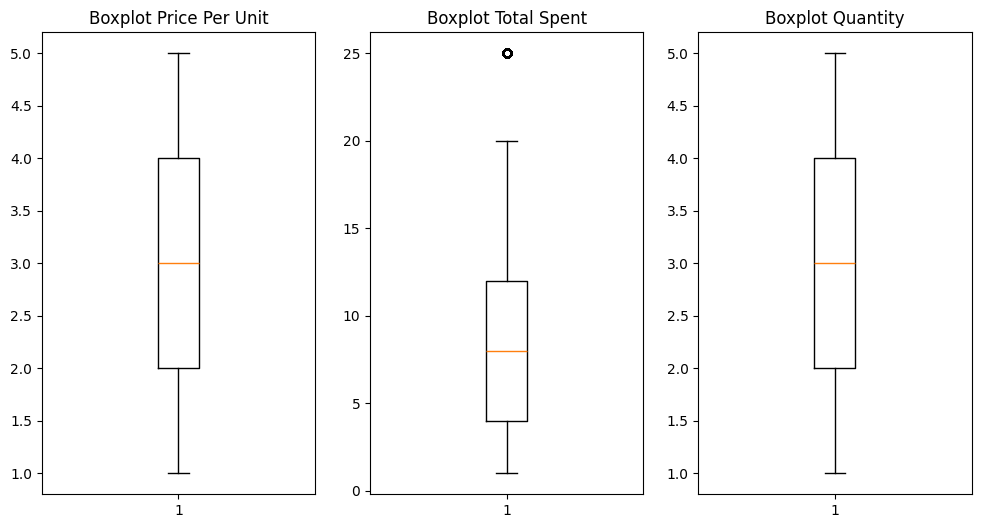

In [46]:
# Tampilkan boxplot untuk Price Per Unit dan Total Spent
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.boxplot(df['Price Per Unit'])
plt.title("Boxplot Price Per Unit")
plt.subplot(1, 3, 2)
plt.boxplot(df['Total Spent'])
plt.title("Boxplot Total Spent")
plt.subplot(1, 3, 3)
plt.boxplot(df['Quantity'])
plt.title("Boxplot Quantity")
plt.show()

In [47]:
# Ada nilai outlier
Q1 = df['Total Spent'].quantile(0.25)
Q3 = df['Total Spent'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Cek outlier
df[(df['Total Spent'] < lower) | (df['Total Spent'] > upper)]

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
10,TXN_2548360,Salad,5.0,5.0,25.0,Cash,Takeaway,2023-11-07
51,TXN_6342161,Salad,5.0,5.0,25.0,Digital Wallet,Takeaway,2023-01-08
52,TXN_8914892,Salad,5.0,5.0,25.0,Digital Wallet,Takeaway,2023-03-15
96,TXN_5220895,Salad,5.0,5.0,25.0,Cash,In-store,2023-06-10
100,TXN_9517146,Salad,5.0,5.0,25.0,Cash,Takeaway,2023-10-30
...,...,...,...,...,...,...,...,...
9791,TXN_1232346,Salad,5.0,5.0,25.0,Digital Wallet,In-store,2023-01-04
9805,TXN_9506076,Salad,5.0,5.0,25.0,Digital Wallet,In-store,2023-01-17
9879,TXN_6393305,Salad,5.0,5.0,25.0,Digital Wallet,In-store,2023-10-19
9908,TXN_8922585,Salad,5.0,5.0,25.0,Credit Card,Takeaway,2023-06-22


In [48]:
# Nilai batas bawah
lower

np.float64(-8.0)

In [49]:
# Nilai batas atas
upper

np.float64(24.0)

In [50]:
# Tidak jadi outlier, outlier secara stastik tapi tidak outlier secara bisnis
# df["Total Spent"] = df["Total Spent"].clip(lower=lower, upper=upper)

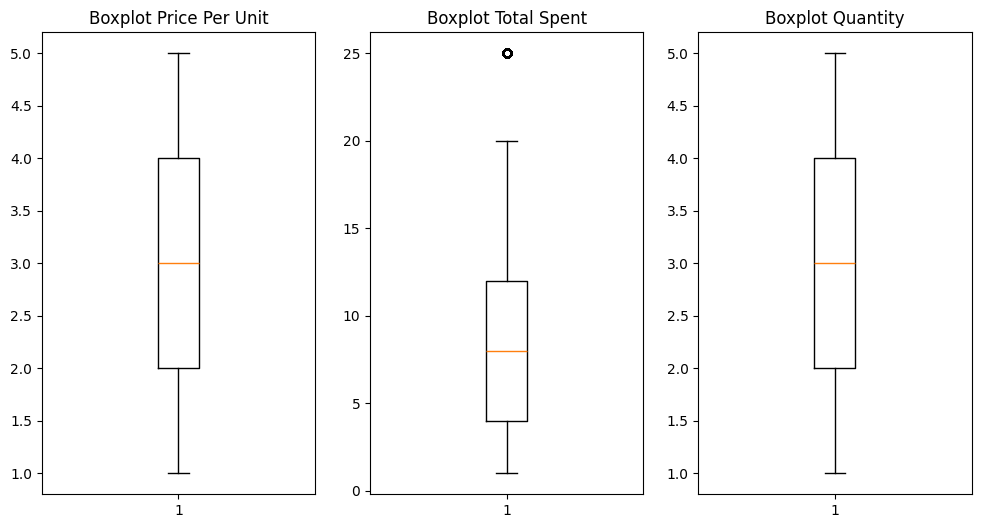

In [51]:
# Tampilkan boxplot untuk Price Per Unit dan Total Spent
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.boxplot(df['Price Per Unit'])
plt.title("Boxplot Price Per Unit")
plt.subplot(1, 3, 2)
plt.boxplot(df['Total Spent'])
plt.title("Boxplot Total Spent")
plt.subplot(1, 3, 3)
plt.boxplot(df['Quantity'])
plt.title("Boxplot Quantity")
plt.show()

# DATA MANIPULATION

Menggunakan  type data dengan benar menggunakan type conversion

In [52]:
# Tipe data sudah diubah guna menampilkan histogram

Melakukan filtering dan sorting data berdasarkan kondisi tertentu.

## Filtering

In [53]:
# Transaksi high-value (Total Spent di atas rata-rata)
df.loc[df['Total Spent'] > df['Total Spent'].mean(), ['Item', 'Quantity', 'Price Per Unit', 'Total Spent']]

,Item,Quantity,Price Per Unit,Total Spent
1,Cake,4.0,3.0,12.0
3,Salad,2.0,5.0,10.0
5,Smoothie,5.0,4.0,20.0
6,Cake,3.0,3.0,9.0
7,Sandwich,4.0,4.0,16.0
...,...,...,...,...
9990,Coffee,5.0,2.0,10.0
9991,Sandwich,3.0,4.0,12.0
9992,Smoothie,4.0,4.0,16.0
9994,Smoothie,4.0,4.0,16.0


In [54]:
# Transaksi quantity besar
df.loc[df['Quantity'] >= 4, 
       ['Item', 'Quantity', 'Price Per Unit', 'Total Spent']]

,Item,Quantity,Price Per Unit,Total Spent
1,Cake,4.0,3.0,12.0
2,Cookie,4.0,1.0,4.0
5,Smoothie,5.0,4.0,20.0
7,Sandwich,4.0,4.0,16.0
8,Juice,5.0,3.0,15.0
...,...,...,...,...
9989,Juice,5.0,3.0,15.0
9990,Coffee,5.0,2.0,10.0
9992,Smoothie,4.0,4.0,16.0
9994,Smoothie,4.0,4.0,16.0


In [55]:
# Kombinasi: transaksi Cash di Takeaway
df[(df['Payment Method'] == 'Cash') & (df['Location'] == 'Takeaway')]

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
6,TXN_4433211,Cake,3.0,3.0,9.0,Cash,Takeaway,2023-10-06
8,TXN_4717867,Juice,5.0,3.0,15.0,Cash,Takeaway,2023-07-28
10,TXN_2548360,Salad,5.0,5.0,25.0,Cash,Takeaway,2023-11-07
18,TXN_8876618,Cake,5.0,3.0,15.0,Cash,Takeaway,2023-03-25
19,TXN_3709394,Juice,4.0,3.0,12.0,Cash,Takeaway,2023-01-15
...,...,...,...,...,...,...,...,...
9971,TXN_6120851,Salad,5.0,5.0,25.0,Cash,Takeaway,2023-02-04
9984,TXN_3142496,Smoothie,1.0,4.0,4.0,Cash,Takeaway,2023-07-27
9987,TXN_1784478,Juice,5.0,3.0,15.0,Cash,Takeaway,2023-07-31
9989,TXN_1741685,Juice,5.0,3.0,15.0,Cash,Takeaway,2023-08-18


## Sorting

In [56]:
# Item paling murah, quantity terbanyak (volume tinggi tapi revenue rendah)
df.sort_values(['Price Per Unit', 'Quantity'], ascending=[True, False]).head(10)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
13,TXN_9437049,Cookie,5.0,1.0,5.0,Digital Wallet,Takeaway,2023-06-01
26,TXN_5183041,Cookie,5.0,1.0,5.0,Credit Card,In-store,2023-04-20
87,TXN_3955361,Cookie,5.0,1.0,5.0,Cash,Takeaway,2023-04-02
89,TXN_4132730,Cookie,5.0,1.0,5.0,Cash,In-store,2023-03-12
108,TXN_4358673,Cookie,5.0,1.0,5.0,Digital Wallet,Takeaway,2023-12-28
226,TXN_6623508,Cookie,5.0,1.0,5.0,Digital Wallet,Takeaway,2023-05-18
394,TXN_8224079,Cookie,5.0,1.0,5.0,Cash,In-store,2023-10-16
418,TXN_1002457,Cookie,5.0,1.0,5.0,Digital Wallet,Takeaway,2023-09-29
475,TXN_2696664,Cookie,5.0,1.0,5.0,Digital Wallet,In-store,2023-01-07
503,TXN_3664656,Cookie,5.0,1.0,5.0,Credit Card,Takeaway,2023-08-13


Menggunakan groupby() untuk melakukan agregasi (misal rata-rata penjualan per kategori).

In [57]:
# Item paling mahal, quantity terbanyak (volume tinggi dan revenue tinggi)
# Buat tabel pivot untuk melihat rata-rata total spent per item dengan nama kolom yang lebih jelas
df.groupby('Item')['Quantity'].mean().sort_values(ascending=False).rename('Average Quantity')

Item
Smoothie    3.072664
Sandwich    3.039932
Coffee      3.034649
Cake        3.026734
Tea         3.015776
Salad       3.001647
Juice       2.996772
Cookie      2.982594
Name: Average Quantity, dtype: float64

In [58]:
df.groupby('Item')['Quantity'].sum().sort_values(ascending=False).rename('Total Quantity')

Item
Coffee      3766.0
Juice       3713.0
Salad       3644.0
Cake        3623.0
Sandwich    3578.0
Smoothie    3552.0
Tea         3441.0
Cookie      3427.0
Name: Total Quantity, dtype: float64

In [59]:
df.groupby('Payment Method')['Total Spent'].mean().sort_values(ascending=False)

Payment Method
Cash              8.973384
Digital Wallet    8.915365
Credit Card       8.872465
Name: Total Spent, dtype: float64

In [60]:
df.groupby('Payment Method')['Total Spent'].sum().sort_values(ascending=False)

Payment Method
Digital Wallet    28547.0
Cash              28320.0
Credit Card       28001.5
Name: Total Spent, dtype: float64

In [61]:
df.groupby('Location')['Total Spent'].mean().sort_values(ascending=False)

Location
In-store    8.992125
Takeaway    8.848485
Name: Total Spent, dtype: float64

In [62]:
df.groupby('Location')['Total Spent'].sum().sort_values(ascending=False)

Location
In-store    42820.5
Takeaway    42048.0
Name: Total Spent, dtype: float64

Membuat kolom baru melalui feature engineering 

In [63]:
df["Month"] = df["Transaction Date"].dt.month

C:\Users\aryac\AppData\Local\Temp\ipykernel_41256\3178290663.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Month"] = df["Transaction Date"].dt.month


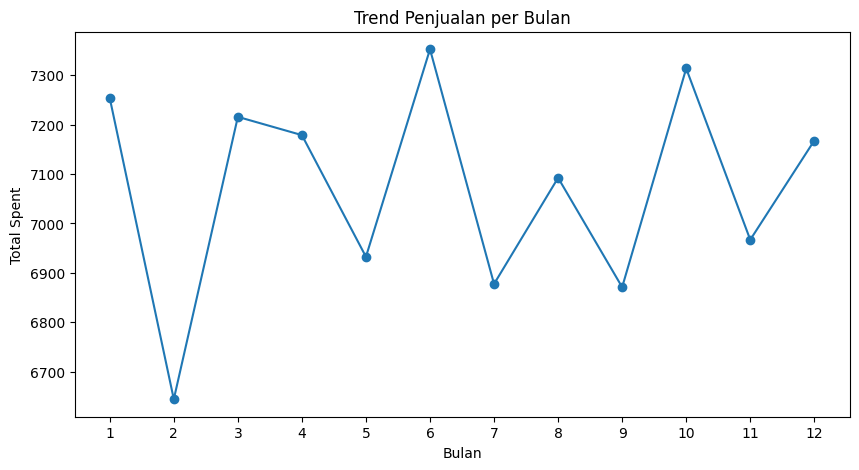

In [64]:
# Trend penjualan per bulan
monthly_sales = df.groupby('Month')['Total Spent'].sum()
plt.figure(figsize=(10, 5))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o')
plt.title("Trend Penjualan per Bulan")
plt.xlabel("Bulan")
plt.ylabel("Total Spent")
plt.xticks(range(1, 13))
plt.show()

In [65]:
# Tampilkan total spent data bulan Februari
print("Total Spent bulan Februari:", df[df['Month'] == 2]['Total Spent'].sum())

Total Spent bulan Februari: 6644.0


In [66]:
df['Is_Total_Valid'] = df['Total Spent'] == (df['Quantity'])*(df['Price Per Unit'])
df

C:\Users\aryac\AppData\Local\Temp\ipykernel_41256\1265558325.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Is_Total_Valid'] = df['Total Spent'] == (df['Quantity'])*(df['Price Per Unit'])


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Month,Is_Total_Valid
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08,9,True
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16,5,True
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-store,2023-07-19,7,True
3,TXN_7034554,Salad,2.0,5.0,10.0,Credit Card,Takeaway,2023-04-27,4,True
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11,6,True
...,...,...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2.0,2.0,4.0,Digital Wallet,Takeaway,2023-08-30,8,True
9996,TXN_9659401,Cookie,3.0,1.0,3.0,Digital Wallet,Takeaway,2023-06-02,6,True
9997,TXN_5255387,Coffee,4.0,2.0,8.0,Digital Wallet,Takeaway,2023-03-02,3,True
9998,TXN_7695629,Cookie,3.0,1.0,3.0,Digital Wallet,In-store,2023-12-02,12,True


In [67]:
df[df["Is_Total_Valid"] == False] # Semua Total Spent Valid, tahap cleaning berjalan dengan aman

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Month,Is_Total_Valid


In [68]:
food = ["Cake", "Cookie", "Salad", "Sandwich"]
drink = ["Coffee", "Juice", "Smoothie", "Tea"]

df['Category'] = df['Item'].apply(lambda x: "Food" if x in food else "Drink")
df

C:\Users\aryac\AppData\Local\Temp\ipykernel_41256\870046984.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Category'] = df['Item'].apply(lambda x: "Food" if x in food else "Drink")


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Month,Is_Total_Valid,Category
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08,9,True,Drink
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16,5,True,Food
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-store,2023-07-19,7,True,Food
3,TXN_7034554,Salad,2.0,5.0,10.0,Credit Card,Takeaway,2023-04-27,4,True,Food
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11,6,True,Drink
...,...,...,...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2.0,2.0,4.0,Digital Wallet,Takeaway,2023-08-30,8,True,Drink
9996,TXN_9659401,Cookie,3.0,1.0,3.0,Digital Wallet,Takeaway,2023-06-02,6,True,Food
9997,TXN_5255387,Coffee,4.0,2.0,8.0,Digital Wallet,Takeaway,2023-03-02,3,True,Drink
9998,TXN_7695629,Cookie,3.0,1.0,3.0,Digital Wallet,In-store,2023-12-02,12,True,Food


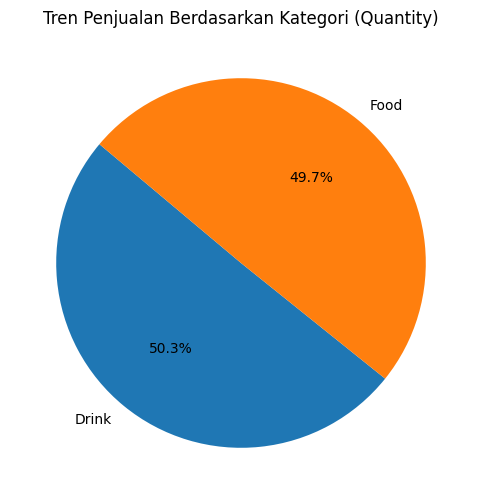

In [69]:
# Tren penjualan berdasarkan kategori
category_sales = df.groupby('Category')['Quantity'].sum()
plt.figure(figsize=(6, 6))
plt.pie(category_sales.values, labels=category_sales.index, autopct='%1.1f%%', startangle=140)
plt.title("Tren Penjualan Berdasarkan Kategori (Quantity)")
plt.show()

Menormalisasikan data yang mengandung outlier menggunakan Scaling

In [70]:
scaler = MinMaxScaler()
df['Quantity'] = scaler.fit_transform(df[['Quantity']])
df['Price Per Unit'] = scaler.fit_transform(df[['Price Per Unit']])
df['Total Spent'] = scaler.fit_transform(df[['Total Spent']])

C:\Users\aryac\AppData\Local\Temp\ipykernel_41256\3638405676.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Quantity'] = scaler.fit_transform(df[['Quantity']])
C:\Users\aryac\AppData\Local\Temp\ipykernel_41256\3638405676.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Price Per Unit'] = scaler.fit_transform(df[['Price Per Unit']])
C:\Users\aryac\AppData\Local\Temp\ipykernel_41256\3638405676.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try

In [71]:
le = LabelEncoder()
df['Item'] = le.fit_transform(df[['Item']])
df['Payment Method'] = le.fit_transform(df[['Payment Method']])
df['Location'] = le.fit_transform(df[['Location']])

c:\Users\aryac\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\aryac\AppData\Local\Temp\ipykernel_41256\2084636404.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Item'] = le.fit_transform(df[['Item']])
c:\Users\aryac\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C

# OUTPUT FINAL DATASET

Menampilkan dataset sebelum siap dianalisis dan sesudah siap dianalisis.

In [72]:
df_raw

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2,2.0,4.0,NaN,UNKNOWN,2023-08-30
9996,TXN_9659401,NaN,3,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3,NaN,3.0,Digital Wallet,NaN,2023-12-02


In [73]:
df

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Month,Is_Total_Valid,Category
0,TXN_1961373,1,0.25,0.25,0.125000,1,1,2023-09-08,9,True,Drink
1,TXN_4977031,0,0.75,0.50,0.458333,0,0,2023-05-16,5,True,Food
2,TXN_4271903,2,0.75,0.00,0.125000,1,0,2023-07-19,7,True,Food
3,TXN_7034554,4,0.25,1.00,0.375000,1,1,2023-04-27,4,True,Food
4,TXN_3160411,1,0.25,0.25,0.125000,2,0,2023-06-11,6,True,Drink
...,...,...,...,...,...,...,...,...,...,...,...
9995,TXN_7672686,1,0.25,0.25,0.125000,2,1,2023-08-30,8,True,Drink
9996,TXN_9659401,2,0.50,0.00,0.083333,2,1,2023-06-02,6,True,Food
9997,TXN_5255387,1,0.75,0.25,0.291667,2,1,2023-03-02,3,True,Drink
9998,TXN_7695629,2,0.50,0.00,0.083333,2,0,2023-12-02,12,True,Food


In [74]:
df_drop

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_3611851,NaN,4.0,NaN,NaN,Credit Card,NaN,2023-02-09
1,TXN_7524977,UNKNOWN,4.0,NaN,NaN,ERROR,NaN,2023-12-09
2,TXN_7376255,UNKNOWN,NaN,NaN,25.0,NaN,In-store,2023-05-27
3,TXN_9646000,ERROR,2.0,NaN,NaN,NaN,In-store,2023-12-14
4,TXN_1082717,ERROR,NaN,NaN,9.0,Digital Wallet,In-store,2023-12-13
...,...,...,...,...,...,...,...,...
481,TXN_9460419,Cake,1.0,3.0,3.0,Credit Card,Takeaway,NaT
482,TXN_8253472,Cake,1.0,3.0,3.0,Credit Card,In-store,NaT
483,TXN_3130865,Juice,3.0,3.0,9.0,Credit Card,In-store,NaT
484,TXN_9226047,Smoothie,3.0,4.0,12.0,Cash,In-store,NaT


In [76]:
df_drop[(df_drop['Item'] == "Cake") & (df_drop['Transaction Date'].isnull())]

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
27,TXN_7640952,Cake,4.0,3.0,12.0,Digital Wallet,Takeaway,NaT
30,TXN_7028009,Cake,4.0,3.0,12.0,Cash,Takeaway,NaT
54,TXN_9762324,Cake,2.0,3.0,6.0,Cash,In-store,NaT
58,TXN_4152036,Cake,2.0,3.0,6.0,Cash,In-store,NaT
65,TXN_3946544,Cake,5.0,3.0,15.0,Credit Card,In-store,NaT
...,...,...,...,...,...,...,...,...
472,TXN_1688292,Cake,3.0,3.0,9.0,Credit Card,In-store,NaT
474,TXN_9686177,Cake,3.0,3.0,9.0,Digital Wallet,In-store,NaT
481,TXN_9460419,Cake,1.0,3.0,3.0,Credit Card,Takeaway,NaT
482,TXN_8253472,Cake,1.0,3.0,3.0,Credit Card,In-store,NaT


In [ ]:
df_drop[df_drop['Transaction Date'].isnull()]['Item'].value_counts() # Tidak ada pola item tertentu yang missing transaction date-nya, semua item hampir sama banyaknya

Item
Tea         65
Cake        63
Cookie      62
Sandwich    60
Salad       56
Smoothie    55
Juice       54
Coffee      45
Name: count, dtype: int64

In [79]:
df_drop[df_drop['Transaction Date'].isnull()]['Payment Method'].value_counts()

Payment Method
Credit Card       166
Digital Wallet    150
Cash              144
Name: count, dtype: int64

In [80]:
df_drop[df_drop['Transaction Date'].isnull()]['Location'].value_counts()

Location
Takeaway    237
In-store    223
Name: count, dtype: int64

Menampilkan ringkasan masalah dan perubahan data (berapa banyak nilai hilang diatasi, duplikat sebelum dan sesudah dihapus ).

In [ ]:
print("Total data setelah preprocessing:", len(df)) # Total 9514 yang sebelumnya 10000
data_hilang = len(df_raw) - len(df)
print("Data yang hilang:", data_hilang)

Total data setelah preprocessing: 9514
Data yang hilang: 486


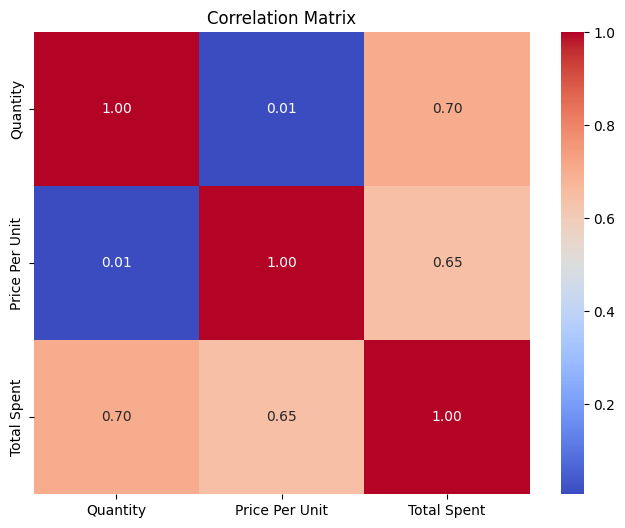

In [ ]:
df = df.drop(columns=['Transaction ID', 'Item', 'Category', 'Transaction Date', 'Is_Total_Valid', 'Payment Method', 'Location', 'Month'])
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()